In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Ashika.B\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')>

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
problem_row = pd.to_numeric(df['TotalCharges'], errors = 'coerce').isna()
print(f"problematic_row:{problem_row.sum()}")
print(df[problem_row] ["TotalCharges"].values)

problematic_row:11
[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print(df['TotalCharges'].dtypes)

float64


In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df = df.dropna()
print(f"rows after dopping null valus: {len(df)}")

rows after dopping null valus: 7032


In [12]:
Churn_rate = df['Churn'].value_counts()
print(Churn_rate)
print(f"Churn_rate : {df['Churn'].value_counts(normalize = True)['Yes'] * 100:.1f}%")

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn_rate : 26.6%


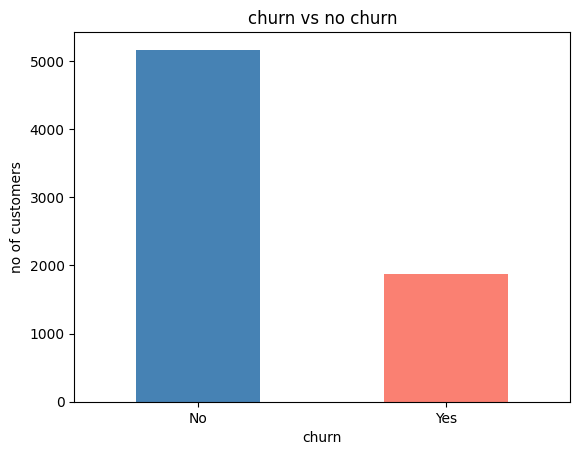

In [13]:
df['Churn'].value_counts().plot(kind = 'bar',  color=['steelblue', 'salmon'])
plt.title("churn vs no churn")
plt.xlabel("churn")
plt.ylabel("no of customers")
plt.xticks(rotation = 0)
plt.show()

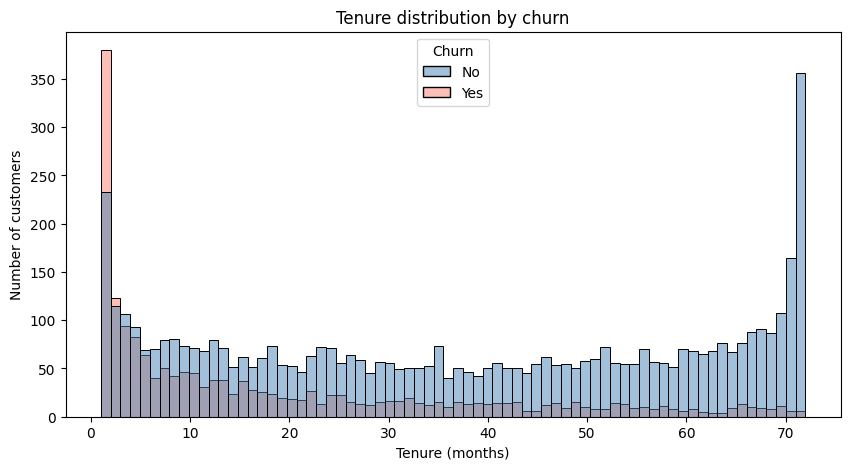

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=72, palette=['steelblue','salmon'])
plt.title('Tenure distribution by churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.show()

In [15]:
df.to_csv("churn_clean.csv", index = False)
print("cleaned data exported")

cleaned data exported


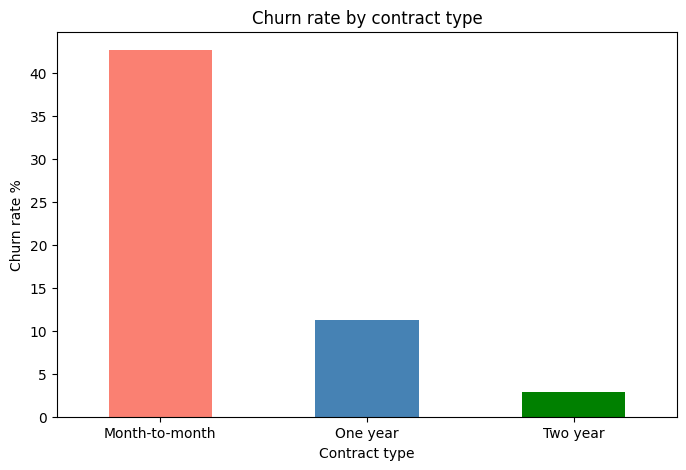

In [16]:
plt.figure(figsize=(8,5))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
contract_churn.plot(kind='bar', color=['salmon','steelblue','green'])
plt.title('Churn rate by contract type')
plt.xlabel('Contract type')
plt.ylabel('Churn rate %')
plt.xticks(rotation=0)
plt.show()

In [17]:
df_encoded = df.copy()
df_encoded = df_encoded.drop('customerID', axis=1)
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)
df_encoded = pd.get_dummies(df_encoded, drop_first=True)
print(df_encoded.shape)

(7032, 31)


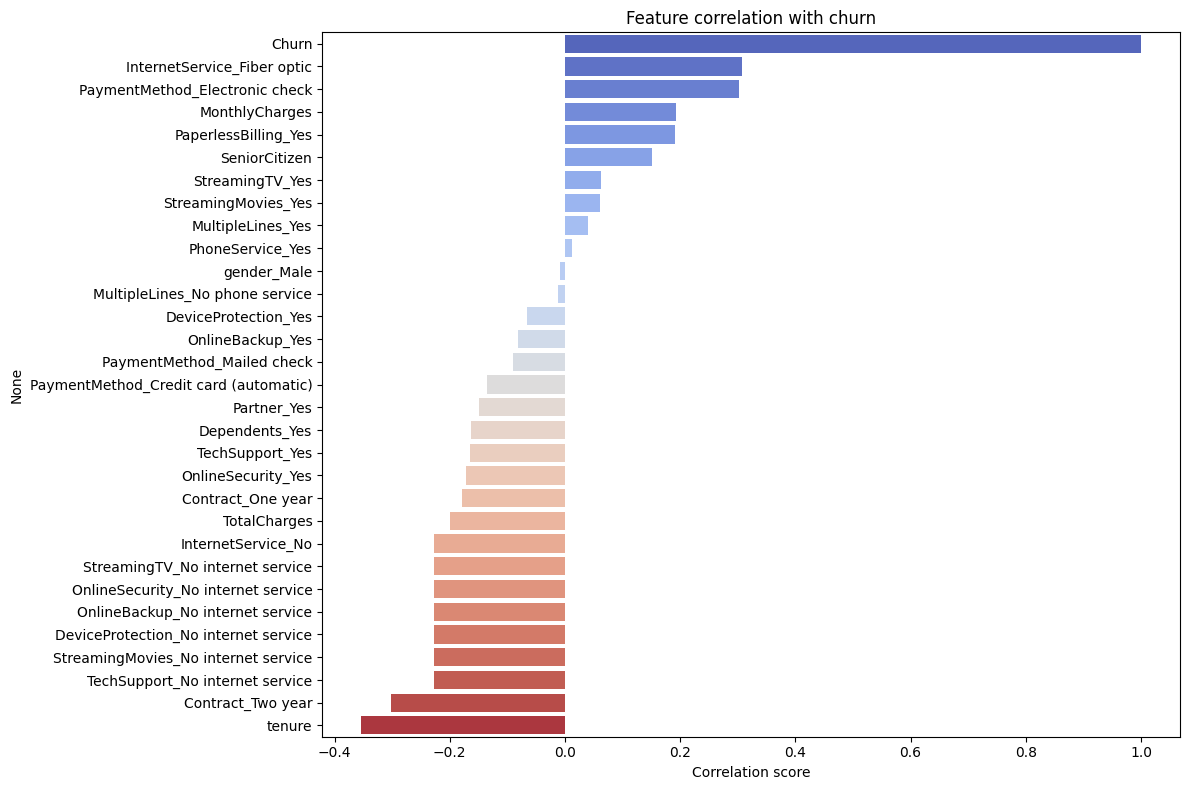

In [18]:
plt.figure(figsize=(12,8))
correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)
sns.barplot(x=correlation.values, y=correlation.index, hue=correlation.index, palette='coolwarm', legend=False)
plt.title('Feature correlation with churn')
plt.xlabel('Correlation score')
plt.tight_layout()
plt.show()

In [19]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (7032, 30)
y shape: (7032,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training customers: {X_train.shape[0]}")
print(f"Testing customers: {X_test.shape[0]}")

Training customers: 5625
Testing customers: 1407


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.1f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 78.7%

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



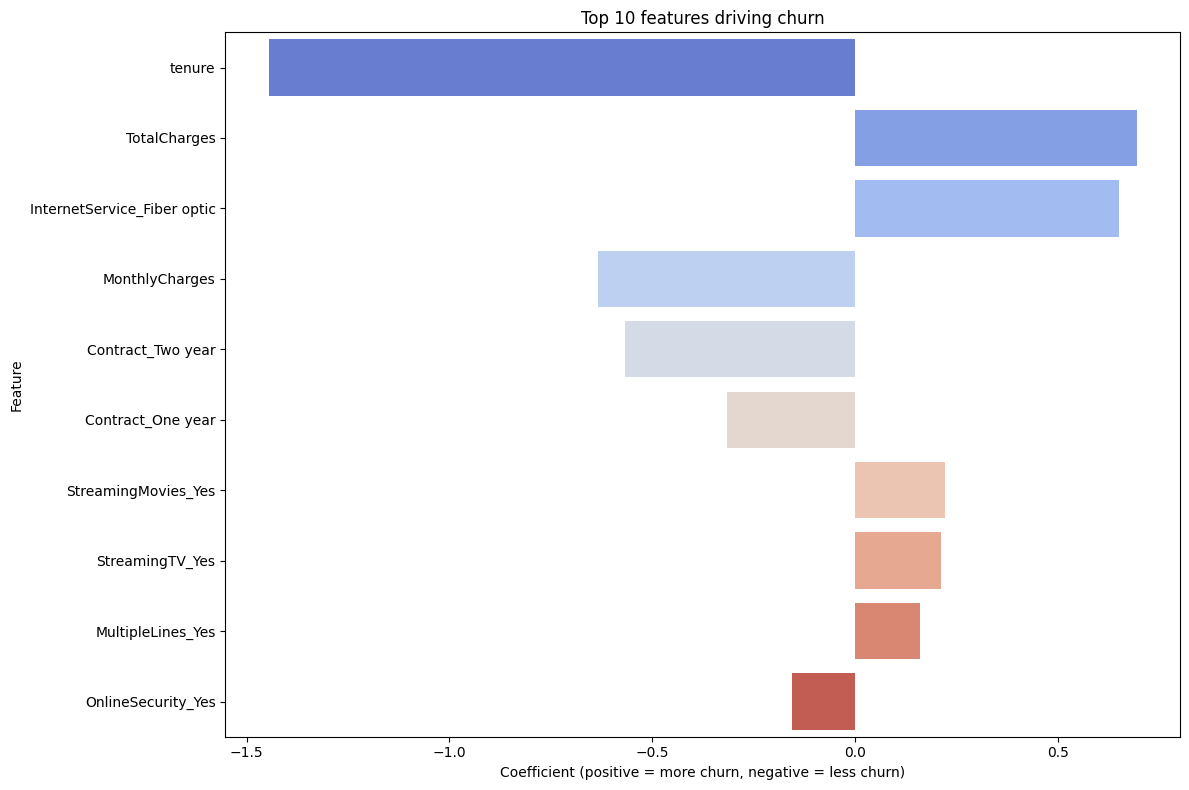

In [24]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importance.head(10), x='Coefficient', y='Feature', 
            hue='Feature', palette='coolwarm', legend=False)
plt.title('Top 10 features driving churn')
plt.xlabel('Coefficient (positive = more churn, negative = less churn)')
plt.tight_layout()
plt.show()

In [25]:
print("=== MODEL SUMMARY ===")
print(f"Total customers tested: 1407")
print(f"Correctly predicted: {accuracy_score(y_test, y_pred) * 100:.1f}%")
print(f"Churners caught: 193 out of 374")
print(f"Churners missed: 181 out of 374")

=== MODEL SUMMARY ===
Total customers tested: 1407
Correctly predicted: 78.7%
Churners caught: 193 out of 374
Churners missed: 181 out of 374
